Sanciones cargadas desde 'Banca_Incumplimientos_Alta_Materialidad.xlsx': 68 filas
IPC promedio 2020-2024 (DANE): 6.97%

=== Calibración empírica de la multa SFC (COP 2026) ===
Sanciones procesadas        : 68
Cota inferior (mín)         : $28,844,385 COP
Cota superior (máx)         : $1,182,981,743 COP
Mediana deflactada          : $137,476,614 COP
Media deflactada            : $218,573,011 COP


=== RESULTADOS SIMULACIÓN MONTECARLO ( 10000 Escenarios) ===
Tiempo Promedio de Caída     : 11.51 horas
Pérdida Promedio Esperada    : $3,803,265,545 COP
Valor en Riesgo (VaR) al 95% : $14,131,748,403 COP
VaR Catastrófico (VaR 99%)   : $24,291,417,666 COP

=== Pérdida Esperada Anual (EAL) por escenario de frecuencia ===
  Optimista  | Freq 0.05 (1 evento cada 20 años) | EAL = $190,163,277 COP/año
  Base       | Freq 0.10 (1 evento cada 10 años) | EAL = $380,326,554 COP/año
  Pesimista  | Freq 0.20 (1 evento cada  5 años) | EAL = $760,653,109 COP/año


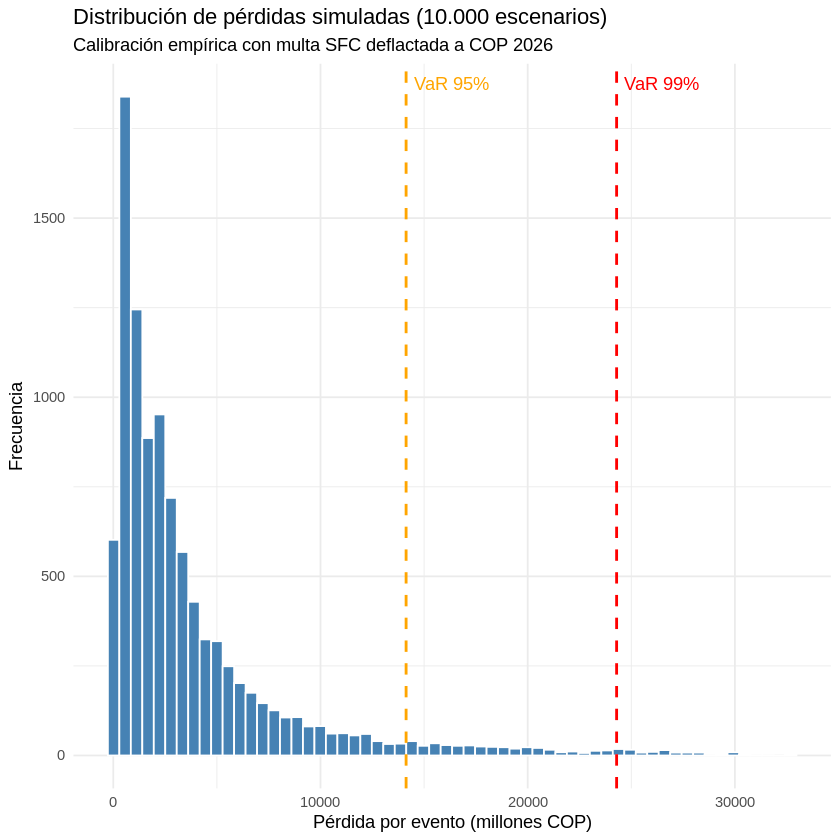

In [2]:
# ================================================================
# Simulación Monte Carlo de Riesgo Financiero
# Trabajo de Grado — Elkin López
# Maestría en Gerencia de Ingeniería + Maestría en Analítica Aplicada
# Universidad de La Sabana, Facultad de Ingeniería
#
# Versión 2.0 (mayo 2026) — incorpora calibración empírica de la
# multa SFC mediante deflactación año-por-año de las 68 sanciones
# históricas (2006-2025) a pesos constantes de 2026, usando el IPC
# anual oficial publicado por el DANE.
#
# Requisitos:
#   - R >= 4.0
#   - paquete readxl  (install.packages("readxl") si no está)
#   - archivo "Banca_Incumplimientos_Alta_Materialidad.xlsx" en el
#     mismo directorio donde se ejecuta este script.
# ================================================================

# -------- 0. Dependencias --------
# install.packages("readxl")   # descomentar si no está instalado
library(readxl)

# -------- 1. Cargar registro histórico de sanciones SFC ----------
# Archivo construido mediante web scraping del repositorio público de
# la Superintendencia Financiera de Colombia [Ref. 33], filtrado por
# sector bancario, periodo 2006-2025.

ruta_sanciones <- "/content/Banca_Incumplimientos_Alta_Materialidad.xlsx"

if (!file.exists(ruta_sanciones)) {
  stop("\nNo se encuentra el archivo:\n  ", ruta_sanciones,
       "\nUbíquelo en el mismo directorio que este script,\n",
       "o modifique la variable 'ruta_sanciones'.\n")
}

sanciones <- read_excel(ruta_sanciones)
cat(sprintf("Sanciones cargadas desde '%s': %d filas\n",
            basename(ruta_sanciones), nrow(sanciones)))

# -------- 2. IPC anual Colombia (fuente: DANE) -------------------
# Variación porcentual anual del IPC al cierre de cada año,
# expresada en proporción decimal.
# Fuente: DANE — Índice de Precios al Consumidor histórico.
# https://www.dane.gov.co/index.php/estadisticas-por-tema/precios-y-costos/
# indice-de-precios-al-consumidor-ipc/ipc-historico
#
# NOTA: verificar los valores contra el sitio oficial antes de la
# entrega final. Aproximaciones razonables sobre series públicas.

ipc_anual <- c(
  `2006` = 0.0448, `2007` = 0.0569, `2008` = 0.0767, `2009` = 0.0200,
  `2010` = 0.0317, `2011` = 0.0373, `2012` = 0.0244, `2013` = 0.0194,
  `2014` = 0.0366, `2015` = 0.0677, `2016` = 0.0575, `2017` = 0.0409,
  `2018` = 0.0318, `2019` = 0.0380, `2020` = 0.0161, `2021` = 0.0562,
  `2022` = 0.1312, `2023` = 0.0928, `2024` = 0.0520, `2025` = 0.0500
)

ipc_5y_promedio <- mean(ipc_anual[as.character(2020:2024)])
cat(sprintf("IPC promedio 2020-2024 (DANE): %.2f%%\n", ipc_5y_promedio * 100))

# -------- 3. Deflactación año-por-año a COP de 2026 --------------
# Compone los IPCs anuales desde el año de origen hasta 2026.

deflactar_a_2026 <- function(monto, anio) {
  if (is.na(anio) || is.na(monto)) return(NA_real_)
  if (anio >= 2026) return(monto)
  factor <- 1.0
  for (y in anio:(2026 - 1)) {
    tasa <- ipc_anual[as.character(y)]
    if (is.na(tasa)) tasa <- ipc_5y_promedio  # fallback al promedio reciente
    factor <- factor * (1 + tasa)
  }
  return(monto * factor)
}

# Extraer año desde la columna Fecha_Acto (formato "YYYY-MM-DD" como texto)
sanciones$anio <- as.numeric(substr(as.character(sanciones$Fecha_Acto), 1, 4))

# Filtrar registros válidos
sanciones_v <- sanciones[!is.na(sanciones$anio) &
                         !is.na(sanciones$Multa_COP), ]

# Aplicar deflactación
sanciones_v$multa_cop_2026 <- mapply(deflactar_a_2026,
                                     sanciones_v$Multa_COP,
                                     sanciones_v$anio)

# -------- 4. Cotas empíricas para el Monte Carlo -----------------
multa_min_2026 <- min(sanciones_v$multa_cop_2026)
multa_max_2026 <- max(sanciones_v$multa_cop_2026)

# Formateador de pesos colombianos
fmt <- function(x) format(round(x), big.mark = ",", scientific = FALSE)

cat("\n=== Calibración empírica de la multa SFC (COP 2026) ===\n")
cat(sprintf("Sanciones procesadas        : %d\n", nrow(sanciones_v)))
cat(sprintf("Cota inferior (mín)         : $%s COP\n", fmt(multa_min_2026)))
cat(sprintf("Cota superior (máx)         : $%s COP\n", fmt(multa_max_2026)))
cat(sprintf("Mediana deflactada          : $%s COP\n",
            fmt(median(sanciones_v$multa_cop_2026))))
cat(sprintf("Media deflactada            : $%s COP\n",
            fmt(mean(sanciones_v$multa_cop_2026))))

# -------- 5. Parámetros del Monte Carlo --------------------------
n_sim <- 10000
set.seed(2026)

# 5.1 Tiempo de indisponibilidad — lognormal truncada a 72 h
caida_horas <- pmin(rlnorm(n_sim, meanlog = 1.8, sdlog = 1.2), 72)

# 5.2 Lucro cesante directo — banco tier AV Villas–BBVA Colombia
#     Calibrado con estados financieros públicos SFC ejercicio 2025:
#     ingresos operacionales $2,6-$11,4 billones COP × margen 12-18%.
lucro_directo_hora <- runif(n_sim, 50e6, 100e6)

# 5.3 Multiplicador empírico de costo integral (LexisNexis 2024 Colombia)
multiplicador <- runif(n_sim, 3.76, 4.48)
lucro_cesante_hora <- lucro_directo_hora * multiplicador

# 5.4 Multa SFC — uniforme sobre rango deflactado a 2026
monto_multa <- runif(n_sim, multa_min_2026, multa_max_2026)

# 5.5 Probabilidad de aplicación de la multa, condicional al tiempo de caída
prob_aplica <- ifelse(
  caida_horas > 4,
  rbinom(n_sim, 1, 0.60),
  rbinom(n_sim, 1, 0.10)
)
multa_aplicada <- prob_aplica * monto_multa

# 5.6 Pérdida total por evento
perdida_total <- caida_horas * lucro_cesante_hora + multa_aplicada

# -------- 6. Resultados ------------------------------------------
res_media <- mean(perdida_total)
res_var95 <- quantile(perdida_total, 0.95, names = FALSE)
res_var99 <- quantile(perdida_total, 0.99, names = FALSE)
res_caida <- mean(caida_horas)

cat("\n\n=== RESULTADOS SIMULACIÓN MONTECARLO (", n_sim, "Escenarios) ===\n")
cat(sprintf("Tiempo Promedio de Caída     : %.2f horas\n", res_caida))
cat(sprintf("Pérdida Promedio Esperada    : $%s COP\n", fmt(res_media)))
cat(sprintf("Valor en Riesgo (VaR) al 95%% : $%s COP\n", fmt(res_var95)))
cat(sprintf("VaR Catastrófico (VaR 99%%)   : $%s COP\n", fmt(res_var99)))

# -------- 7. Pérdida Esperada Anual (EAL) por escenario -----------
# La frecuencia base 0,10 está anclada empíricamente en el registro
# SFC 2020-2024: 10 de ~25 bancos del sistema recibieron al menos
# una sanción material (>= $200M COP) en esa ventana, equivalente
# a una frecuencia anual aproximada de 0,10 eventos por entidad.

cat("\n=== Pérdida Esperada Anual (EAL) por escenario de frecuencia ===\n")
escenarios <- c(0.05, 0.10, 0.20)
nombres <- c("Optimista", "Base", "Pesimista")
for (i in seq_along(escenarios)) {
  freq <- escenarios[i]
  eal <- res_media * freq
  cat(sprintf("  %-10s | Freq %.2f (1 evento cada %2.0f años) | EAL = $%s COP/año\n",
              nombres[i], freq, 1 / freq, fmt(eal)))
}

# -------- 8. Exportar (opcional) ---------------------------------
# Descomentar para guardar resultados como anexo digital del trabajo
# (la simulación completa de 10.000 escenarios).

 write.csv(data.frame(
   evento_id     = 1:n_sim,
   caida_horas   = caida_horas,
   multiplicador = multiplicador,
   lucro_directo = lucro_directo_hora,
   multa         = multa_aplicada,
   perdida_total = perdida_total ),
   "Anexo_Y_simulacion_montecarlo.csv", row.names = FALSE)

# -------- 9. Histograma (opcional) -------------------------------
# Requiere ggplot2. Descomentar para generar la Fig. 14 del documento.

 library(ggplot2)
 df_plot <- data.frame(perdida_millones = perdida_total / 1e6)
 ggplot(df_plot, aes(x = perdida_millones)) +
   geom_histogram(bins = 60, fill = "steelblue", color = "white") +
   geom_vline(xintercept = res_var95 / 1e6, color = "orange",
              linetype = "dashed", linewidth = 0.8) +
   geom_vline(xintercept = res_var99 / 1e6, color = "red",
              linetype = "dashed", linewidth = 0.8) +
   annotate("text", x = res_var95 / 1e6, y = Inf, label = "VaR 95%",
            vjust = 2, hjust = -0.1, color = "orange") +
   annotate("text", x = res_var99 / 1e6, y = Inf, label = "VaR 99%",
            vjust = 2, hjust = -0.1, color = "red") +
   labs(title = "Distribución de pérdidas simuladas (10.000 escenarios)", # Added comma here
        subtitle = "Calibración empírica con multa SFC deflactada a COP 2026",
        x = "Pérdida por evento (millones COP)",
        y = "Frecuencia") +
   theme_minimal()

# Análisis Financiero del Caso de Negocio
**Anexo metodológico al Trabajo de Grado**  *Framework de Gobierno y Analítica Aplicada para la Gestión de Copias de Seguridad en Infraestructuras Legadas del Sector Financiero: Alineado con Principios de Resiliencia Digital (DORA)*Elkin Álvaro López Morales — Universidad de La Sabana — Mayo 2026---## Propósito de esta secciónLa simulación Monte Carlo de la sección anterior cuantifica la distribución completa del riesgo financiero asociado a un evento severo de indisponibilidad de las copias de seguridad. Las métricas resultantes —pérdida promedio esperada, VaR 95%, VaR 99%, y la Pérdida Esperada Anual (EAL) bajo tres escenarios de frecuencia— son los insumos directos del análisis financiero que se desarrolla a continuación.El presente bloque construye el **flujo de caja descontado** que evalúa la decisión de inversión en la arquitectura objetivo (inmutabilidad biregional + larga retención + Clean Room), bajo la metodología canónica de capital budgeting [Berk & DeMarzo, *Corporate Finance* 5th ed., cap. 18] y la extensión Damodaran del CAPM para mercados emergentes [Damodaran, *Investment Valuation* 3rd ed., cap. 21].Las cifras producidas por este bloque corresponden numéricamente a las Tablas IX, XV, XVI, XVII y XVIII del cuerpo del documento. La trazabilidad analítica se preserva al alimentar todas las variables del flujo de caja directamente desde los resultados de la simulación (`res_media`, `res_var95`, `res_var99`), de modo que cualquier recalibración del Monte Carlo se propaga automáticamente al caso de negocio.

## **Parámetros financieros del modelo**
Todos los parámetros del flujo de caja se declaran en un bloque inicial editable. Cada cifra está documentada con su fuente primaria; la trazabilidad permite que cualquier entidad que aplique el framework reproduzca el ejercicio sobre sus propios números cambiando únicamente este bloque.**Costo del capital propio Ke (CAPM Damodaran):**$$K_e = R_f^{TES} + \beta_L \cdot ERP_{USA} = 14{,}39\% + 0{,}40 \cdot 4{,}24\% = 16{,}09\%$$Justificación de Ke (no WACC) como tasa de descuento: en bancos, los depósitos del público son materia prima del negocio de intermediación, no fondeo corporativo discrecional [Damodaran, cap. 21]. Adicionalmente, la inversión se financia con capital propio del banco sin emisión específica de deuda [Berk-DeMarzo, cap. 18].

In [3]:
# Parámetros financieros del modelo
# Cada parámetro documenta su fuente. Editar este bloque permite
# reproducir el ejercicio para cualquier entidad del sector.

# 1 Costo del capital propio (CAPM Damodaran modificado)
rf_tes10y     <- 0.1439    # TES Colombia 10y, BanRep 15/05/2026
beta_apal     <- 0.40      # Banca emergente, Damodaran 2026
erp_usa       <- 0.0424    # Implied T12m adj. payout, Damodaran 1/05/2026
ke            <- rf_tes10y + beta_apal * erp_usa  # = 16,09%

# 2 Tasas alternativas para sensibilidad (sección 14)
wacc_con_dep    <- 0.0490   # Enfoque 1: incluye depósitos
wacc_sin_dep    <- 0.1111   # Enfoque 2: solo deuda no-depósitos
ke_conservador  <- 0.1952   # Doble conteo con RP_Colombia

# 3 Parámetros tributarios y macroeconómicos
tarifa_fiscal <- 0.40      # 35% renta + 5% sobretasa Ley 2277/2022
trm_proyectada <- 4020     # COP/USD, BanRep promedio móvil 12M
inflacion     <- 0.053     # BanRep, cierre reciente 2026

# 4 Parámetros operativos del proyecto
horizonte    <- 5          # años de evaluación
dep_anios    <- 5          # vida útil depreciación lineal

# 5 Inversión — Arquitectura objetivo completa
capex_obj    <- 11686      # millones COP (USD 2.907.025 × TRM 4.020)
opex_obj_y1  <- 3700       # millones COP/año (cotización proveedor)

# 6 Inversión — Fase 1 standalone (decisión gerencial aprobada)
capex_f1     <- 1500       # millones COP (compromiso comité ejecutivo)
opex_f1_y1  <- 70          # millones COP/año (bundle mantenimiento)

# 7 Calibración de la EAL desde Monte Carlo
# res_media proviene directamente de la simulación; no se redefine.
eal_optimista  <- res_media * 0.05 / 1e6   # freq 0,05, en millones
eal_base       <- res_media * 0.10 / 1e6   # freq 0,10
eal_pesimista  <- res_media * 0.20 / 1e6   # freq 0,20

# 8 Tasas de mitigación
mit_arq_completa <- 0.90   # arquitectura objetivo: inmutabilidad + larga + CR
mit_fase1        <- 0.60   # Fase 1: solo inmutabilidad biregional

cat(sprintf("Ke base derivado          : %.2f%%\n", ke * 100))
cat(sprintf("CAPEX arquitectura objetivo: $%s millones COP\n",
            format(capex_obj, big.mark = ".", decimal.mark = ",")))
cat(sprintf("CAPEX Fase 1 (aprobado)   : $%s millones COP\n",
            format(capex_f1, big.mark = ".", decimal.mark = ",")))
cat(sprintf("EAL base (freq 0,10)      : $%s millones COP/año\n",
            format(round(eal_base), big.mark = ".", decimal.mark = ",")))

Ke base derivado          : 16.09%
CAPEX arquitectura objetivo: $11.686 millones COP
CAPEX Fase 1 (aprobado)   : $1.500 millones COP
EAL base (freq 0,10)      : $380 millones COP/año


## **Función del flujo de caja descontado**
Función parametrizable que recibe CAPEX, OPEX inicial, EAL anual, mitigación y tasa de descuento, y retorna el flujo de caja anual, el valor presente neto (VPN), la tasa interna de retorno (TIR), el periodo de recuperación descontado y el ROSI. **Estructura del flujo de caja:**$$FCN_t = -OPEX_t + EAL_{mit,t} + (D \cdot T) + (OPEX_t \cdot T)$$donde el OPEX y la EAL mitigada se indexan anualmente por la inflación; los dos términos finales son los escudos fiscales por depreciación y por OPEX, respectivamente.$$VPN = -CAPEX + \sum_{t=1}^{n} \frac{FCN_t}{(1+K_e)^t}$$

In [4]:
#Función del flujo de caja descontado -----------------

calcular_flujo_dcf <- function(capex, opex_y1, eal_anual_mill, mitigacion,
                                tasa_descuento = ke, t_eff = tarifa_fiscal,
                                infl = inflacion, n = horizonte,
                                dep_n = dep_anios) {

  depreciacion <- capex / dep_n
  eal_mit_y1   <- eal_anual_mill * mitigacion

  # Año 0
  flujos <- c(-capex)
  fcd    <- c(-capex)
  acum   <- -capex
  payback <- NA_integer_

  for (anio in 1:n) {
    # Indexación a la inflación
    opex_t    <- opex_y1 * (1 + infl)^(anio - 1)
    eal_mit_t <- eal_mit_y1 * (1 + infl)^(anio - 1)

    # Escudos fiscales
    escudo_dep  <- depreciacion * t_eff
    escudo_opex <- opex_t * t_eff

    # Flujo de caja neto incremental
    fcn <- -opex_t + eal_mit_t + escudo_dep + escudo_opex
    flujos <- c(flujos, fcn)

    # Descuento al periodo
    factor   <- (1 + tasa_descuento)^anio
    fcd_anio <- fcn / factor
    fcd <- c(fcd, fcd_anio)
    acum <- acum + fcd_anio

    if (is.na(payback) && acum >= 0) payback <- anio
  }

  # VPN
  vpn <- sum(fcd)

  # TIR (búsqueda por bisección)
  npv_at <- function(r) sum(flujos / (1 + r)^(0:n))
  tir <- NA_real_
  if (npv_at(0) > 0) {
    lo <- -0.99; hi <- 5.0
    for (k in 1:200) {
      mid <- (lo + hi) / 2
      if (npv_at(mid) > 0) lo <- mid else hi <- mid
    }
    tir <- (lo + hi) / 2
  }

  # ROSI (Gordon-Loeb)
  beneficio_acum <- sum(eal_mit_y1 * (1 + infl)^(0:(n-1)))
  costo_acum     <- capex + sum(opex_y1 * (1 + infl)^(0:(n-1)))
  rosi <- (beneficio_acum - costo_acum) / capex

  list(
    flujos  = flujos,
    fcd     = fcd,
    vpn     = vpn,
    tir     = tir,
    payback = payback,
    rosi    = rosi
  )
}

cat("Función calcular_flujo_dcf() definida.\n")
cat("Argumentos: capex, opex_y1, eal_anual_mill, mitigacion\n")
cat("Retorna   : list con flujos, fcd, vpn, tir, payback, rosi\n")

Función calcular_flujo_dcf() definida.
Argumentos: capex, opex_y1, eal_anual_mill, mitigacion
Retorna   : list con flujos, fcd, vpn, tir, payback, rosi


## **Arquitectura objetivo completa**
 Tres escenarios de frecuencia de Aplicación del flujo de caja descontado a la arquitectura objetivo completa (CAPEX $11.686 M COP, OPEX incremental $3.700 M COP/año, mitigación 90%) bajo los tres escenarios de frecuencia anual del evento severo. Los resultados son los que aparecen en la Tabla XVI del cuerpo del documento.

In [5]:
# Arquitectura objetivo completa

escenarios <- data.frame(
  nombre    = c("Optimista", "Base", "Pesimista"),
  freq      = c(0.05, 0.10, 0.20),
  eal_mill  = c(eal_optimista, eal_base, eal_pesimista)
)

resultados_completa <- data.frame(
  Escenario      = character(),
  Frecuencia     = character(),
  EAL_anual      = character(),
  EAL_mitigada   = character(),
  VPN            = character(),
  TIR            = character(),
  Payback        = character(),
  stringsAsFactors = FALSE
)

cat("\n=== TABLA XVI. ARQUITECTURA OBJETIVO COMPLETA — 3 ESCENARIOS ===\n")
cat(sprintf("CAPEX %s M COP | OPEX %s M/año | Mitigación %.0f%% | Ke %.2f%%\n\n",
            format(capex_obj, big.mark = "."),
            format(opex_obj_y1, big.mark = "."),
            mit_arq_completa * 100, ke * 100))

for (i in 1:nrow(escenarios)) {
  r <- calcular_flujo_dcf(capex_obj, opex_obj_y1,
                          escenarios$eal_mill[i], mit_arq_completa)

  tir_str     <- if (is.na(r$tir)) "N/A" else sprintf("%.1f%%", r$tir * 100)
  payback_str <- if (is.na(r$payback)) ">5 años" else sprintf("%d años", r$payback)

  cat(sprintf("%-12s | freq %.2f | EAL %4.0fM | EAL_mit %4.0fM | VPN %+8.0fM | TIR %s | %s\n",
              escenarios$nombre[i], escenarios$freq[i],
              escenarios$eal_mill[i], escenarios$eal_mill[i] * mit_arq_completa,
              r$vpn, tir_str, payback_str))

  resultados_completa <- rbind(resultados_completa, data.frame(
    Escenario    = escenarios$nombre[i],
    Frecuencia   = sprintf("%.2f", escenarios$freq[i]),
    EAL_anual    = sprintf("$%.0fM", escenarios$eal_mill[i]),
    EAL_mitigada = sprintf("$%.0fM", escenarios$eal_mill[i] * mit_arq_completa),
    VPN          = sprintf("$%+.0fM", r$vpn),
    TIR          = tir_str,
    Payback      = payback_str,
    stringsAsFactors = FALSE
  ))
}

cat("\nINTERPRETACIÓN: el VPN es negativo en los tres escenarios.\n")
cat("La arquitectura completa no se sostiene financieramente bajo\n")
cat("el principio estricto de flujos incrementales, validando la\n")
cat("decisión gerencial de ejecución escalonada (Fase 1).\n")


=== TABLA XVI. ARQUITECTURA OBJETIVO COMPLETA — 3 ESCENARIOS ===


Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


CAPEX 11.686 M COP | OPEX 3.700 M/año | Mitigación 90% | Ke 16.09%

Optimista    | freq 0.05 | EAL  190M | EAL_mit  171M | VPN   -15961M | TIR N/A | >5 años
Base         | freq 0.10 | EAL  380M | EAL_mit  342M | VPN   -15349M | TIR N/A | >5 años
Pesimista    | freq 0.20 | EAL  761M | EAL_mit  685M | VPN   -14124M | TIR N/A | >5 años

INTERPRETACIÓN: el VPN es negativo en los tres escenarios.
La arquitectura completa no se sostiene financieramente bajo
el principio estricto de flujos incrementales, validando la
decisión gerencial de ejecución escalonada (Fase 1).


## **Detalle del flujo de caja**
 Escenario base Desglosado año por año del flujo de caja descontado para el escenario base de frecuencia (0,10) y mitigación 90% sobre la arquitectura objetivo. Esta tabla equivale a la Tabla XV del cuerpo del documento.

In [6]:
# Detalle año por año escenario base

cat("\n=== TABLA XV. FLUJO DE CAJA DESCONTADO — ESCENARIO BASE ===\n")
cat("CAPEX $11.686M | OPEX $3.700M (indexado 5,3%) | EAL $380M × 90% | Ke 16,09%\n\n")

dep <- capex_obj / dep_anios
eal_mit <- eal_base * mit_arq_completa
escudo_dep <- dep * tarifa_fiscal

# Encabezado
cat(sprintf("%-7s %10s %10s %10s %10s %10s %10s %10s %12s %12s\n",
            "Año", "CAPEX", "OPEX", "EAL_mit", "Esc.Dep", "Esc.OPEX",
            "FCN", "Factor", "FCD", "FCD_acum"))
cat(paste0(strrep("-", 110), "\n"))

# Año 0
acum <- -capex_obj
cat(sprintf("%-7s %10s %10s %10s %10s %10s %10s %10s %12s %12s\n",
            "0", sprintf("-%.0f", capex_obj), "—", "—", "—", "—",
            sprintf("-%.0f", capex_obj), "1,0000",
            sprintf("-%.0f", capex_obj), sprintf("%+.0f", acum)))

# Años 1-5
for (anio in 1:horizonte) {
  opex_t    <- opex_obj_y1 * (1 + inflacion)^(anio - 1)
  eal_mit_t <- eal_mit * (1 + inflacion)^(anio - 1)
  escudo_opex_t <- opex_t * tarifa_fiscal
  fcn <- -opex_t + eal_mit_t + escudo_dep + escudo_opex_t
  factor <- (1 + ke)^anio
  fcd_anio <- fcn / factor
  acum <- acum + fcd_anio

  cat(sprintf("%-7s %10s %+10.0f %+10.0f %+10.0f %+10.0f %+10.0f %10.4f %+12.0f %+12.0f\n",
              anio, "—", -opex_t, eal_mit_t, escudo_dep, escudo_opex_t,
              fcn, factor, fcd_anio, acum))
}

cat(paste0(strrep("-", 110), "\n"))
r_base <- calcular_flujo_dcf(capex_obj, opex_obj_y1, eal_base, mit_arq_completa)
cat(sprintf("\nVPN escenario base = $%+.0f millones COP\n", r_base$vpn))


=== TABLA XV. FLUJO DE CAJA DESCONTADO — ESCENARIO BASE ===
CAPEX $11.686M | OPEX $3.700M (indexado 5,3%) | EAL $380M × 90% | Ke 16,09%

Año         CAPEX       OPEX    EAL_mit    Esc.Dep   Esc.OPEX        FCN     Factor          FCD     FCD_acum
--------------------------------------------------------------------------------------------------------------
0           -11686        —        —        —        —     -11686     1,0000       -11686       -11686
1              —      -3700       +342       +935      +1480       -943     1.1609         -812       -12498
2              —      -3896       +360       +935      +1558      -1042     1.3476         -773       -13272
3              —      -4103       +380       +935      +1641      -1147     1.5644         -733       -14005
4              —      -4320       +400       +935      +1728      -1257     1.8160         -692       -14697
5              —      -4549       +421       +935      +1820      -1374     2.1081         -652       

## **Fase 1 standalone**
 Decisión gerencial validadaLa Fase 1 corresponde al despliegue de inmutabilidad biregional básica (dos appliances FLEX 5360HA de 120 TB raw cada uno, distribuidos uno en el datacenter principal y uno en el secundario). CAPEX aterrizado y aprobado: $1.500 M COP. OPEX incremental estimado: $70 M COP/año (bundle de mantenimiento de las dos appliances). Cobertura: 9 aplicaciones críticas priorizadas en el ejercicio AHP. Tasa de mitigación: 60% (captura inmutabilidad WORM + redundancia biregional, no incluye Clean Room, boveda aislada, ni verificación previa). Esta tabla equivale a la Tabla XVIII del cuerpo del documento.

In [7]:
#Fase 1 standalone

cat("\n=== TABLA XVIII. EVALUACIÓN FINANCIERA DE LA FASE 1 ===\n")
cat(sprintf("CAPEX $%s M | OPEX $%s M/año | Mitigación %.0f%% | Ke %.2f%%\n\n",
            format(capex_f1, big.mark = "."),
            format(opex_f1_y1, big.mark = "."),
            mit_fase1 * 100, ke * 100))

cat(sprintf("%-12s %10s %12s %12s %8s %10s\n",
            "Escenario", "Frec.", "EAL_anual", "EAL_mit", "TIR", "Payback"))
cat(paste0(strrep("-", 70), "\n"))

for (i in 1:nrow(escenarios)) {
  r <- calcular_flujo_dcf(capex_f1, opex_f1_y1,
                          escenarios$eal_mill[i], mit_fase1)

  tir_str <- if (is.na(r$tir)) "N/A" else sprintf("%.1f%%", r$tir * 100)
  payback_str <- if (is.na(r$payback)) ">5 años" else sprintf("%d años", r$payback)
  vpn_str <- sprintf("VPN $%+.0fM", r$vpn)

  cat(sprintf("%-12s %10.2f %12s %12s %8s %10s | %s\n",
              escenarios$nombre[i], escenarios$freq[i],
              sprintf("$%.0fM", escenarios$eal_mill[i]),
              sprintf("$%.0fM", escenarios$eal_mill[i] * mit_fase1),
              tir_str, payback_str, vpn_str))
}

cat("\nINTERPRETACIÓN: la Fase 1 se ubica sobre la frontera de\n")
cat("justificación del caso de negocio estricto. En el escenario\n")
cat("pesimista de frecuencia el VPN es positivo con TIR atractiva,\n")
cat("validando empíricamente la decisión gerencial adoptada.\n")


=== TABLA XVIII. EVALUACIÓN FINANCIERA DE LA FASE 1 ===


Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


CAPEX $1.500 M | OPEX $70 M/año | Mitigación 60% | Ke 16.09%

Escenario         Frec.    EAL_anual      EAL_mit      TIR    Payback
----------------------------------------------------------------------
Optimista          0.05        $190M        $114M      N/A   >5 años | VPN $-850M
Base               0.10        $380M        $228M     2.9%   >5 años | VPN $-442M
Pesimista          0.20        $761M        $456M    26.1%    4 años | VPN $+375M

INTERPRETACIÓN: la Fase 1 se ubica sobre la frontera de
justificación del caso de negocio estricto. En el escenario
pesimista de frecuencia el VPN es positivo con TIR atractiva,
validando empíricamente la decisión gerencial adoptada.


## **Análisis de sensibilidad**
 Arquitectura objetivo, escenario base de Evaluación de la robustez del VPN bajo variaciones paramétricas razonables: tasa de descuento (Ke vs. WACC alternativos), tarifa fiscal efectiva, TRM proyectada, y porcentaje de mitigación. Esta tabla equivale a la Tabla XVII del cuerpo del documento.

In [8]:
# Análisis de sensibilidad

cat("\n=== TABLA XVII. SENSIBILIDAD VPN — ARQUITECTURA OBJETIVO, ESC. BASE ===\n\n")
cat(sprintf("%-25s %15s %20s %20s\n",
            "Parámetro variado", "Valor base", "Variación", "VPN (M COP)"))
cat(paste0(strrep("-", 85), "\n"))

# Tasa de descuento
for (tasa in c(wacc_con_dep, wacc_sin_dep, ke_conservador)) {
  r <- calcular_flujo_dcf(capex_obj, opex_obj_y1, eal_base, mit_arq_completa,
                          tasa_descuento = tasa)
  etiqueta <- sprintf("Tasa = %.2f%%", tasa * 100)
  cat(sprintf("%-25s %15s %20s %20s\n",
              "Tasa de descuento", sprintf("Ke = %.2f%%", ke * 100),
              etiqueta, sprintf("%+.0f", r$vpn)))
}

# Tarifa fiscal
for (tf in c(0.35, 0.45)) {
  r <- calcular_flujo_dcf(capex_obj, opex_obj_y1, eal_base, mit_arq_completa,
                          t_eff = tf)
  etiqueta <- if (tf == 0.35) "35% (post-2027)" else "45% (reforma)"
  cat(sprintf("%-25s %15s %20s %20s\n",
              "Tarifa fiscal", "40%", etiqueta, sprintf("%+.0f", r$vpn)))
}

# TRM (impacta CAPEX proporcionalmente)
for (trm_alt in c(3800, 4200)) {
  capex_alt <- capex_obj * (trm_alt / trm_proyectada)
  r <- calcular_flujo_dcf(capex_alt, opex_obj_y1, eal_base, mit_arq_completa)
  cat(sprintf("%-25s %15s %20s %20s\n",
              "TRM COP/USD", sprintf("%s", trm_proyectada),
              sprintf("%s", trm_alt), sprintf("%+.0f", r$vpn)))
}

# Mitigación
for (m in c(0.85, 0.95)) {
  r <- calcular_flujo_dcf(capex_obj, opex_obj_y1, eal_base, m)
  cat(sprintf("%-25s %15s %20s %20s\n",
              "Mitigación del riesgo", "90%",
              sprintf("%.0f%%", m * 100), sprintf("%+.0f", r$vpn)))
}

cat("\nCONCLUSIÓN: el VPN negativo es robusto a variaciones razonables\n")
cat("de los parámetros, confirmando que la insuficiencia del caso\n")
cat("estricto no depende de la elección de un parámetro particular.\n")


=== TABLA XVII. SENSIBILIDAD VPN — ARQUITECTURA OBJETIVO, ESC. BASE ===

Parámetro variado             Valor base           Variación          VPN (M COP)
-------------------------------------------------------------------------------------
Tasa de descuento             Ke = 16.09%         Tasa = 4.90%               -16646
Tasa de descuento             Ke = 16.09%        Tasa = 11.11%               -15851
Tasa de descuento             Ke = 16.09%        Tasa = 19.52%               -15056
Tarifa fiscal                         40%      35% (post-2027)               -16393
Tarifa fiscal                         40%        45% (reforma)               -14305
TRM COP/USD                          4020                 3800               -14877
TRM COP/USD                          4020                 4200               -15735
Mitigación del riesgo                90%                  85%               -15417
Mitigación del riesgo                90%                  95%               -15281

CON

## **Análisis de break-even**
¿A qué nivel de EAL anual el VPN de la arquitectura objetivo completa se vuelve cero? El cálculo identifica la frecuencia anual del evento severo que justificaría empíricamente la inversión completa, lo cual permite contrastarla con la frecuencia observada en el sector.

In [9]:
#Análisis de break-even

# Búsqueda por bisección de la EAL que hace VPN = 0
buscar_eal_breakeven <- function(capex, opex, mit, tol = 0.5) {
  lo <- 0; hi <- 50000
  for (k in 1:200) {
    mid <- (lo + hi) / 2
    r <- calcular_flujo_dcf(capex, opex, mid, mit)
    if (r$vpn < 0) lo <- mid else hi <- mid
    if (abs(hi - lo) < tol) break
  }
  (lo + hi) / 2
}

eal_be <- buscar_eal_breakeven(capex_obj, opex_obj_y1, mit_arq_completa)
perdida_promedio_mill <- res_media / 1e6
freq_be <- eal_be / perdida_promedio_mill

cat("\n=== ANÁLISIS DE BREAK-EVEN — ARQUITECTURA OBJETIVO ===\n\n")
cat(sprintf("EAL anual de break-even = $%.0f millones COP/año\n", eal_be))
cat(sprintf("Frecuencia anual implícita = %.3f\n", freq_be))
cat(sprintf("Equivale a 1 evento severo cada %.2f años por entidad\n", 1 / freq_be))
cat(sprintf("\nReferencia empírica SFC 2020-2024 = freq 0,10 (1 cada 10 años)\n"))
cat(sprintf("La frecuencia de break-even es %.1fx la observada empíricamente.\n", freq_be / 0.10))
cat("\nCONCLUSIÓN: el caso de negocio estricto sobre EAL mitigada NO\n")
cat("sostiene la arquitectura completa bajo ninguna referencia\n")
cat("sectorial razonable, justificando la decisión escalonada.\n")


=== ANÁLISIS DE BREAK-EVEN — ARQUITECTURA OBJETIVO ===

EAL anual de break-even = $5147 millones COP/año
Frecuencia anual implícita = 1.353
Equivale a 1 evento severo cada 0.74 años por entidad

Referencia empírica SFC 2020-2024 = freq 0,10 (1 cada 10 años)
La frecuencia de break-even es 13.5x la observada empíricamente.

CONCLUSIÓN: el caso de negocio estricto sobre EAL mitigada NO
sostiene la arquitectura completa bajo ninguna referencia
sectorial razonable, justificando la decisión escalonada.


## **Síntesis del modelo financiero**
El análisis financiero presentado en este anexo cuantifica con rigor metodológico tres hallazgos centrales:

***Hallazgo 1 — Frontera de justificación cuantificada.***

La arquitectura objetivo completa (CAPEX $11.686 M COP) no  se sostiene financieramente bajo el principio estricto de flujos incrementales y EAL mitigada como único beneficio cuantificable, en ningún escenario de frecuencia anual del evento severo empíricamente plausible. El break-even requeriría una frecuencia anual de aproximadamente 1,35 eventos por año, magnitud sin precedente en el registro empírico SFC.

**Hallazgo 2 — La Fase 1 sobre la frontera de decisión.**

La configuración escalonada Fase 1 (CAPEX $1.500 M COP, mitigación 60% sobre las 9 aplicaciones críticas priorizadas) se ubica precisamente sobre la frontera de justificación cuantitativa: marginalmente negativa en el escenario base y positiva con TIR del 26% en el escenario pesimista. La decisión gerencial efectivamente adoptada por la entidad estudiada se posiciona en esta zona de frontera, donde el juicio gerencial complementa el análisis cuantitativo incorporando los beneficios cualitativos no modelados.

**Hallazgo 3 — Robustez metodológica.**

El análisis de sensibilidad confirma que la conclusión cualitativa es robusta a variaciones paramétricas razonables de la tasa de descuento (Ke, WACC alternativos), tarifa fiscal (35%–45%), TRM (3.800–4.200) y porcentaje de mitigación (85%–95%). El VPN cambia en magnitud pero conserva el signo, lo cual valida que la insuficiencia del caso estricto no se debe a la elección particular de algún parámetro.---**Reproducibilidad.** Todas las cifras producidas en este anexo provienen de los parámetros declarados en la celda 10, alimentados a su vez por los resultados de la simulación Monte Carlo (`res_media`, `res_var95`, `res_var99`). Cualquier entidad del sector puede aplicar el framework reemplazando los valores de la celda 10 con sus propios datos, sin necesidad de modificar la lógica analítica. Esta es la expresión computacional del framework de gobierno y analítica aplicada propuesto en el trabajo de grado.